# **Import môi trường**

In [20]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from dotenv import load_dotenv
from fredapi import Fred

# **Đọc FRED API key**

In [2]:
project_root = Path.cwd()
env_path = project_root / ".env"

load_dotenv(env_path)

fred_api_key = os.getenv("FRED_API_KEY")

if fred_api_key is None:
    raise ValueError(
        "Không tìm thấy FRED_API_KEY. Hãy kiểm tra file .env."
    )

print("Đã tìm thấy FRED API key.")

Đã tìm thấy FRED API key.


# **Khởi tạo kết nối FRED**

In [3]:
fred = Fred(api_key=fred_api_key)

print("Đã khởi tạo kết nối FRED.")

Đã khởi tạo kết nối FRED.


# **Lấy thử dữ liệu Treasury bill**

In [5]:
# Lấy dữ liệu Treasury Bill 3-Month (TB3MS) từ FRED bắt đầu từ ngày 1 tháng 1 năm 2024
tb3ms_test = fred.get_series(
    "TB3MS",
    observation_start="2024-01-01"
)

tb3ms_test.tail()

2024-01-01    5.22
2024-02-01    5.24
2024-03-01    5.24
2024-04-01    5.24
2024-05-01    5.25
dtype: float64

In [6]:
# Kiểm tra thông tin về chuỗi dữ liệu TB3MS
tb3ms_info = fred.get_series_info("TB3MS")

tb3ms_info[
    [
        "title",
        "units",
        "frequency",
        "seasonal_adjustment",
        "observation_start",
        "observation_end"
    ]
]

title                  3-Month Treasury Bill Secondary Market Rate, D...
units                                                            Percent
frequency                                                        Monthly
seasonal_adjustment                              Not Seasonally Adjusted
observation_start                                             1934-01-01
observation_end                                               2026-07-01
dtype: str

# **1. Nominal interest rate**

The nominal interest rate is represented by the three-month U.S. Treasury
bill secondary market rate.

- FRED series: `TB3MS`
- Unit: Percent per year
- Frequency: Monthly
- Seasonal adjustment: Not seasonally adjusted
- Source: Federal Reserve Board, H.15 Selected Interest Rates

In [7]:
# Xác định ngày bắt đầu phân tích
START_DATE = "2000-01-01"

print(f"Analysis starts from: {START_DATE}")

Analysis starts from: 2000-01-01


In [8]:
# Lấy dữ liệu Treasury Bill 3-Month (TB3MS) từ FRED bắt đầu từ ngày 1 tháng 1 năm 2000
tb3ms = fred.get_series(
    "TB3MS",
    observation_start=START_DATE
)

type(tb3ms) 

pandas.Series

In [9]:
# Tạo DataFrame cho lãi suất danh nghĩa
nominal_df = (
    tb3ms
    .rename("nominal_rate")
    .to_frame()
)

nominal_df.index.name = "date"

nominal_df.head()

,nominal_rate
date,
2000-01-01,5.32
2000-02-01,5.55
2000-03-01,5.69
2000-04-01,5.66
2000-05-01,5.79


In [11]:
display("Dữ liệu đầu: ", nominal_df.head())
display("Dữ liệu cuối: ", nominal_df.tail())

'Dữ liệu đầu: '

,nominal_rate
date,
2000-01-01,5.32
2000-02-01,5.55
2000-03-01,5.69
2000-04-01,5.66
2000-05-01,5.79


'Dữ liệu cuối: '

,nominal_rate
date,
2026-03-01,3.61
2026-04-01,3.61
2026-05-01,3.60
2026-06-01,3.66
2026-07-01,3.73


In [13]:
# Kiểm tra số lượng quan sát và số lượng cột trong DataFrame
print(f"Number of observations: {len(nominal_df)}")
print(f"Number of columns: {nominal_df.shape[1]}")

Number of observations: 319
Number of columns: 1


In [14]:
nominal_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 319 entries, 2000-01-01 to 2026-07-01
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   nominal_rate  319 non-null    float64
dtypes: float64(1)
memory usage: 5.0 KB


In [15]:
# Kiểm tra giá trị thiếu trong DataFrame
missing_values = nominal_df.isna().sum()

missing_values

nominal_rate    0
dtype: int64

In [16]:
# kiểm tra các ngày trùng lặp trong DataFrame
duplicate_dates = nominal_df.index.duplicated().sum()

print("Number of duplicate dates:", duplicate_dates)

Number of duplicate dates: 0


In [17]:
nominal_df["nominal_rate"].describe()

count    319.000000
mean       1.927743
std        1.928863
min        0.010000
25%        0.120000
50%        1.290000
75%        3.685000
max        6.170000
Name: nominal_rate, dtype: float64

In [18]:
# Tìm tháng có lãi suất danh nghĩa thấp nhất
minimum_date = nominal_df["nominal_rate"].idxmin()
minimum_value = nominal_df.loc[minimum_date, "nominal_rate"]

print("Minimum date:", minimum_date)
print("Minimum rate:", minimum_value)

Minimum date: 2011-09-01 00:00:00
Minimum rate: 0.01


In [19]:
# Tìm tháng có lãi suất danh nghĩa cao nhất
maximum_date = nominal_df["nominal_rate"].idxmax()
maximum_value = nominal_df.loc[maximum_date, "nominal_rate"]

print("Maximum date:", maximum_date)
print("Maximum rate:", maximum_value)

Maximum date: 2000-11-01 00:00:00
Maximum rate: 6.17


In [23]:
# Lưu dữ liệu thành CSV
raw_data_directory = project_root / "data" / "raw"
raw_data_directory.mkdir(parents=True, exist_ok=True)

nominal_file = raw_data_directory / "tb3ms_monthly.csv"
nominal_df.to_csv(nominal_file)

print(f"Saved to: {nominal_file}")

Saved to: d:\Project_Intern\us-real-interest-rate-analysis\data\raw\tb3ms_monthly.csv


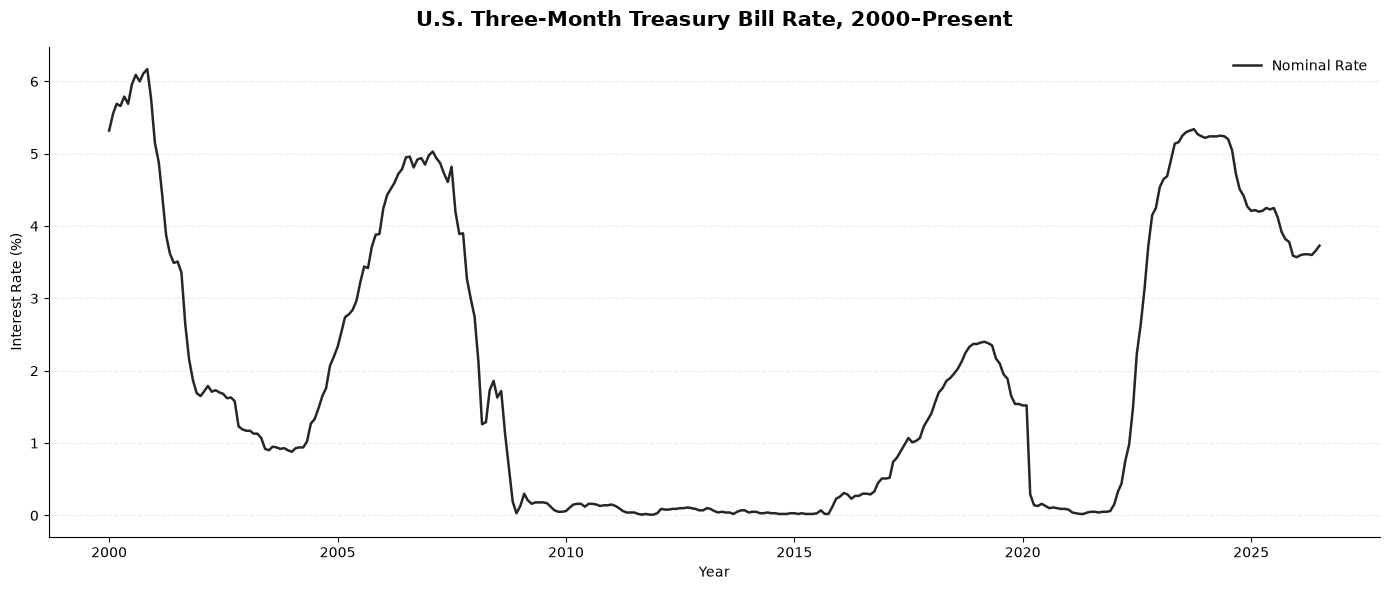

Figure saved to: d:\Project_Intern\us-real-interest-rate-analysis\outputs\tb3ms_nominal_rate.png


In [24]:
# Vẽ biểu đồ lãi suất danh nghĩa theo thời gian
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    nominal_df.index,
    nominal_df["nominal_rate"],
    color="#262626",
    linewidth=1.8,
    label="Nominal Rate"
)

ax.set_title(
    "U.S. Three-Month Treasury Bill Rate, 2000–Present",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Year")
ax.set_ylabel("Interest Rate (%)")

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()

output_directory = project_root / "outputs"
output_directory.mkdir(parents=True, exist_ok=True)

figure_file = output_directory / "tb3ms_nominal_rate.png"

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_file}")

# **2. Expected inflation**

Expected inflation is represented by the Cleveland Fed's one-year expected
inflation estimate.

- FRED series: `EXPINF1YR`
- Unit: Percent per year
- Frequency: Monthly
- Source: Federal Reserve Bank of Cleveland
- Method: Model-based estimate

Expected inflation is not directly observable. The Cleveland Fed estimates it
using information from Treasury yields, inflation data, inflation swaps, and
survey-based inflation expectations.

The expected real interest rate is approximated as:

\[
r_t^{ex\ ante} \approx i_t - \pi_t^e
\]

In [25]:
# Lấy thông tin về lạm phát dự kiến trong 1 năm (EXPINF1YR) từ FRED
expected_inflation_info = fred.get_series_info("EXPINF1YR")

expected_inflation_info[
    [
        "title",
        "units",
        "frequency",
        "seasonal_adjustment",
        "observation_start",
        "observation_end"
    ]
]

title                  1-Year Expected Inflation
units                                    Percent
frequency                                Monthly
seasonal_adjustment      Not Seasonally Adjusted
observation_start                     1982-01-01
observation_end                       2026-08-01
dtype: str

In [26]:
# Lấy dữ liệu lạm phát dự kiến trong 1 năm (EXPINF1YR) từ FRED bắt đầu từ ngày 1 tháng 1 năm 2000
expected_inflation = fred.get_series(
    "EXPINF1YR",
    observation_start=START_DATE
)

type(expected_inflation)

pandas.Series

In [27]:
# Tạo DataFrame cho lạm phát dự kiến
expected_df = (
    expected_inflation
    .rename("expected_inflation")
    .to_frame()
)

expected_df.index.name = "date"

expected_df.head()

,expected_inflation
date,
2000-01-01,3.080288
2000-02-01,3.157068
2000-03-01,3.238857
2000-04-01,3.160674
2000-05-01,3.312626


In [28]:
display("Dữ liệu đầu: ", expected_df.head())
display("Dữ liệu cuối: ", expected_df.tail())

'Dữ liệu đầu: '

,expected_inflation
date,
2000-01-01,3.080288
2000-02-01,3.157068
2000-03-01,3.238857
2000-04-01,3.160674
2000-05-01,3.312626


'Dữ liệu cuối: '

,expected_inflation
date,
2026-04-01,3.276398
2026-05-01,3.535256
2026-06-01,3.038866
2026-07-01,2.386001
2026-08-01,2.393703


In [29]:
print("Number of observations:", len(expected_df))
print("Start date:", expected_df.index.min())
print("End date:", expected_df.index.max())

Number of observations: 320
Start date: 2000-01-01 00:00:00
End date: 2026-08-01 00:00:00


In [30]:
expected_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 320 entries, 2000-01-01 to 2026-08-01
Data columns (total 1 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   expected_inflation  320 non-null    float64
dtypes: float64(1)
memory usage: 5.0 KB


In [31]:
# Kiểm tra giá trị thiếu
expected_df.isna().sum()

expected_inflation    0
dtype: int64

In [32]:
# Kiểm tra ngày trùng lặp trong DataFrame
print(
    "Number of duplicate dates:",
    expected_df.index.duplicated().sum()
)

Number of duplicate dates: 0


In [33]:
expected_df["expected_inflation"].describe()

count    320.000000
mean       2.090451
std        0.690604
min       -0.480678
25%        1.649175
50%        2.074494
75%        2.615469
max        4.226713
Name: expected_inflation, dtype: float64

In [34]:
# Tìm tháng có lạm phát dự kiến thấp nhất
minimum_date = expected_df["expected_inflation"].idxmin()
minimum_value = expected_df.loc[minimum_date, "expected_inflation"]

print(f"Tháng có lạm phát dự kiến thấp nhất: {minimum_date}")
print(f"Giá trị lạm phát dự kiến thấp nhất: {minimum_value}")

Tháng có lạm phát dự kiến thấp nhất: 2009-03-01 00:00:00
Giá trị lạm phát dự kiến thấp nhất: -0.48067803


In [35]:
# Tìm tháng có lạm phát dự kiến cao nhất
maximum_date = expected_df["expected_inflation"].idxmax()
maximum_value = expected_df.loc[maximum_date, "expected_inflation"]

print(f"Tháng có lạm phát dự kiến cao nhất: {maximum_date}")
print(f"Giá trị lạm phát dự kiến cao nhất: {maximum_value}")

Tháng có lạm phát dự kiến cao nhất: 2022-06-01 00:00:00
Giá trị lạm phát dự kiến cao nhất: 4.22671337


In [38]:
# Lưu dữ liệu lạm phát dự kiến thành CSV
expected_file = raw_data_directory / "expected_inflation.csv"
expected_df.to_csv(expected_file)
print(f"Saved to: {expected_file}")

Saved to: d:\Project_Intern\us-real-interest-rate-analysis\data\raw\expected_inflation.csv


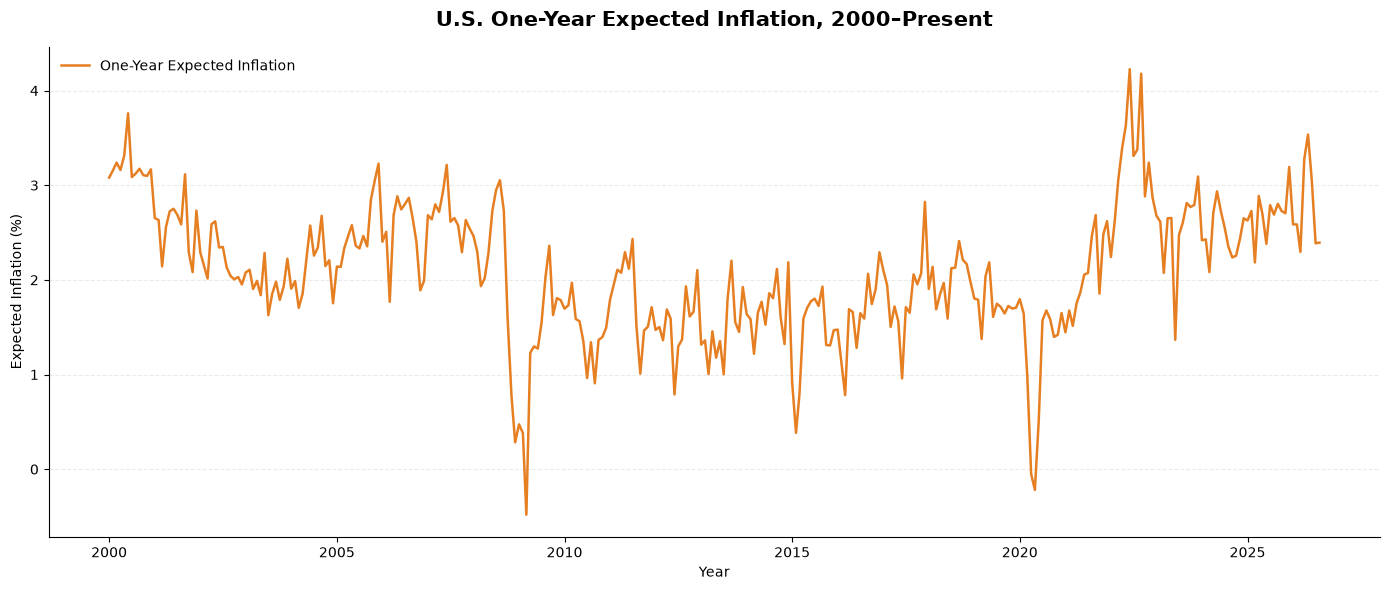

Figure saved to: d:\Project_Intern\us-real-interest-rate-analysis\outputs\expected_inflation.png


In [40]:
# Vẽ biểu đồ lạm phát kỳ vọng
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    expected_df.index,
    expected_df["expected_inflation"],
    color="#E67E22",
    linewidth=1.8,
    label="One-Year Expected Inflation"
)

ax.set_title(
    "U.S. One-Year Expected Inflation, 2000–Present",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Year")
ax.set_ylabel("Expected Inflation (%)")

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()

figure_file = output_directory / "expected_inflation.png"

fig.savefig(figure_file, dpi=300, bbox_inches="tight")

plt.show()
print(f"Figure saved to: {figure_file}")

# **3. Estimated ex-ante real interest rate**

In [49]:
# Ghép dữ liệu lãi suất danh nghĩa và lạm phát dự kiến thành một DataFrame hợp nhất
# outer join giữ lại tất cả tháng xuất hiện trong ít nhất một chuỗi
# nhưng bị thiếu mất tháng 8/2026 vì bên norminal rate chưa có dữ liệu
audit_df = nominal_df.join(expected_df, how="outer")

audit_df.tail(10)

,nominal_rate,expected_inflation
date,,
2025-11-01,3.78,2.703875
2025-12-01,3.59,3.192869
2026-01-01,3.57,2.586395
2026-02-01,3.60,2.585698
2026-03-01,3.61,2.295295
2026-04-01,3.61,3.276398
2026-05-01,3.60,3.535256
2026-06-01,3.66,3.038866
2026-07-01,3.73,2.386001


In [50]:
# Kiểm tra giá trị thiếu trong DataFrame hợp nhất
audit_df.isna().sum()

nominal_rate          1
expected_inflation    0
dtype: int64

In [51]:
missing_rows = audit_df[audit_df.isna().any(axis=1)]

missing_rows

,nominal_rate,expected_inflation
date,,
2026-08-01,NaN,2.393703


In [52]:
# Chuyển sang inner join để chỉ giữ lại các tháng có dữ liệu đầy đủ cho cả lãi suất danh nghĩa và lạm phát dự kiến
analysis_df = nominal_df.join(expected_df,how="inner")

analysis_df = analysis_df.dropna()

analysis_df.tail()

,nominal_rate,expected_inflation
date,,
2026-03-01,3.61,2.295295
2026-04-01,3.61,3.276398
2026-05-01,3.60,3.535256
2026-06-01,3.66,3.038866
2026-07-01,3.73,2.386001


In [53]:
# Kiểm tra số lượng quan sát và số lượng cột trong DataFrame hợp nhất
print("Number of observations:", len(analysis_df))
print("Start date:", analysis_df.index.min())
print("End date:", analysis_df.index.max())

print("\nMissing values:")
print(analysis_df.isna().sum())

print("\nDuplicate dates:", analysis_df.index.duplicated().sum())

print("Inferred frequency:", pd.infer_freq(analysis_df.index))

Number of observations: 319
Start date: 2000-01-01 00:00:00
End date: 2026-07-01 00:00:00

Missing values:
nominal_rate          0
expected_inflation    0
dtype: int64

Duplicate dates: 0
Inferred frequency: MS


In [54]:
# Tính lãi suất theo công thức sấp xỉ
analysis_df["real_rate_approx"] = (analysis_df["nominal_rate"] - analysis_df["expected_inflation"])

In [ ]:
# Tính theo công thức Fisher chính xác
nominal_decimal = (
    analysis_df["nominal_rate"] / 100
)

expected_inflation_decimal = (
    analysis_df["expected_inflation"] / 100
)

analysis_df["real_rate_exact"] = (
    (
        (1 + nominal_decimal)
        / (1 + expected_inflation_decimal)
    ) - 1
) * 100

In [56]:
analysis_df.head()

,nominal_rate,expected_inflation,real_rate_approx,real_rate_exact
date,,,,
2000-01-01,5.32,3.080288,2.239712,2.172784
2000-02-01,5.55,3.157068,2.392932,2.319698
2000-03-01,5.69,3.238857,2.451143,2.374245
2000-04-01,5.66,3.160674,2.499327,2.422751
2000-05-01,5.79,3.312626,2.477374,2.397940


In [57]:
analysis_df.tail()

,nominal_rate,expected_inflation,real_rate_approx,real_rate_exact
date,,,,
2026-03-01,3.61,2.295295,1.314705,1.285206
2026-04-01,3.61,3.276398,0.333602,0.323019
2026-05-01,3.60,3.535256,0.064744,0.062534
2026-06-01,3.66,3.038866,0.621134,0.602815
2026-07-01,3.73,2.386001,1.343999,1.312678


In [58]:
sample_date = analysis_df.index[-1]
sample_row = analysis_df.loc[sample_date]

print("Date:", sample_date.strftime("%Y-%m"))
print(
    "Nominal rate:",
    round(sample_row["nominal_rate"], 2),
    "%"
)
print(
    "Expected inflation:",
    round(sample_row["expected_inflation"], 2),
    "%"
)
print(
    "Approximate real rate:",
    round(sample_row["real_rate_approx"], 2),
    "%"
)
print(
    "Exact real rate:",
    round(sample_row["real_rate_exact"], 2),
    "%"
)

Date: 2026-07
Nominal rate: 3.73 %
Expected inflation: 2.39 %
Approximate real rate: 1.34 %
Exact real rate: 1.31 %


In [59]:
# So sánh 2 công thức
analysis_df["formula_difference"] = (analysis_df["real_rate_approx"] - analysis_df["real_rate_exact"])

analysis_df[
    [
        "real_rate_approx",
        "real_rate_exact",
        "formula_difference"
    ]].describe()

,real_rate_approx,real_rate_exact,formula_difference
count,319.000000,319.000000,319.000000
mean,-0.161757,-0.162483,0.000726
std,1.548613,1.512844,0.036705
min,-2.736713,-2.625731,-0.110982
25%,-1.393219,-1.371847,-0.023004
50%,-0.674806,-0.664410,-0.010397
75%,0.979893,0.955757,0.024531
max,3.793737,3.742604,0.092310


In [87]:
# Xác định lãi suất thực âm
# Nếu lãi suất thực âm thì cột "negative_real_rate" sẽ là True, ngược lại là False
analysis_df["negative_real_rate"] = (
    analysis_df["real_rate_approx"] < 0
)

# Xem các tháng có lãi suất thực âm
negative_rate_df = analysis_df[
    analysis_df["negative_real_rate"]
]
# In bảng các tháng có lãi suất thực âm
negative_rate_df.tail()

,nominal_rate,expected_inflation,real_rate_approx,real_rate_exact,formula_difference,negative_real_rate
date,,,,,,
2022-05-01,0.98,3.634658,-2.654658,-2.561554,-0.093104,True
2022-06-01,1.49,4.226713,-2.736713,-2.625731,-0.110982,True
2022-07-01,2.23,3.309278,-1.079278,-1.044705,-0.034572,True
2022-08-01,2.63,3.377132,-0.747132,-0.722724,-0.024407,True
2022-09-01,3.13,4.179150,-1.049150,-1.007063,-0.042087,True


Lãi suất thực âm xảy ra khi lãi suất thực (real interest rate) nhỏ hơn 0, tức là khi lãi suất danh nghĩa (nominal interest rate) thấp hơn mức lạm phát dự kiến (expected inflation). Trong trường hợp này, người gửi tiền sẽ mất giá trị thực của số tiền gửi theo thời gian, vì lạm phát làm giảm sức mua của đồng tiền

In [65]:
# Tính số lượng tháng có lãi suất thực âm và tỷ lệ phần trăm so với tổng số tháng
number_negative_months = (analysis_df["negative_real_rate"].sum())

total_months = len(analysis_df)

negative_share = (number_negative_months / total_months) * 100

print("Number of negative-real-rate months:", number_negative_months)

print("Share of negative-real-rate months:", round(negative_share, 2), "%")

Number of negative-real-rate months: 197
Share of negative-real-rate months: 61.76 %


Có thể thấy số lượng tháng có lãi suất thực âm là 197 tháng, chiếm 61.76% tổng số tháng từ năm 2000 đến nay. Điều này cho thấy rằng trong khoảng thời gian này, có một tỷ lệ đáng kể các tháng mà lãi suất thực tế đã giảm xuống dưới mức 0, điều này có thể phản ánh các điều kiện kinh tế và chính sách tiền tệ đặc biệt trong giai đoạn đó

In [66]:
# Tìm mức lãi suất thực thấp nhất và cao nhất cùng với ngày tương ứng
real_min_date = (analysis_df["real_rate_approx"].idxmin())

real_max_date = (analysis_df["real_rate_approx"].idxmax())

print("Lowest real rate:", round(analysis_df.loc[real_min_date, "real_rate_approx"], 2), "%")
print("Lowest real-rate date:", real_min_date)

print("\nHighest real rate:", round(analysis_df.loc[real_max_date,"real_rate_approx"], 2), "%")
print("Highest real-rate date:", real_max_date)

Lowest real rate: -2.74 %
Lowest real-rate date: 2022-06-01 00:00:00

Highest real rate: 3.79 %
Highest real-rate date: 2023-06-01 00:00:00


In [85]:
analysis_df = analysis_df[
    [
        "nominal_rate",
        "expected_inflation",
        "real_rate_approx",
        "real_rate_exact",
        "formula_difference",
        "negative_real_rate"
    ]
]

analysis_df.tail()

,nominal_rate,expected_inflation,real_rate_approx,real_rate_exact,formula_difference,negative_real_rate
date,,,,,,
2026-03-01,3.61,2.295295,1.314705,1.285206,0.029499,False
2026-04-01,3.61,3.276398,0.333602,0.323019,0.010583,False
2026-05-01,3.60,3.535256,0.064744,0.062534,0.002211,False
2026-06-01,3.66,3.038866,0.621134,0.602815,0.018319,False
2026-07-01,3.73,2.386001,1.343999,1.312678,0.031321,False


In [68]:
processed_data_directory = (project_root / "data" / "processed")

processed_data_directory.mkdir(parents=True, exist_ok=True)

processed_file = (
    processed_data_directory
    / "real_interest_rate_ex_ante.csv"
)

analysis_df.to_csv(processed_file)

print(f"Saved to: {processed_file}")

Saved to: d:\Project_Intern\us-real-interest-rate-analysis\data\processed\real_interest_rate_ex_ante.csv


# **4. Nominal and estimated real interest rates**

The following figure reconstructs and updates Mishkin's chart of nominal and
estimated real short-term interest rates.

The nominal rate is the three-month Treasury bill rate. The estimated real rate
is calculated by subtracting one-year expected inflation from the nominal rate

In [69]:
# Xác định khoảng thời gian của biểu đồ
chart_start_date = analysis_df.index.min()
chart_end_date = analysis_df.index.max()

chart_start_year = chart_start_date.year
chart_end_year = chart_end_date.year

print(
    f"Chart period: "
    f"{chart_start_date.strftime('%Y-%m')} "
    f"to {chart_end_date.strftime('%Y-%m')}"
)

Chart period: 2000-01 to 2026-07


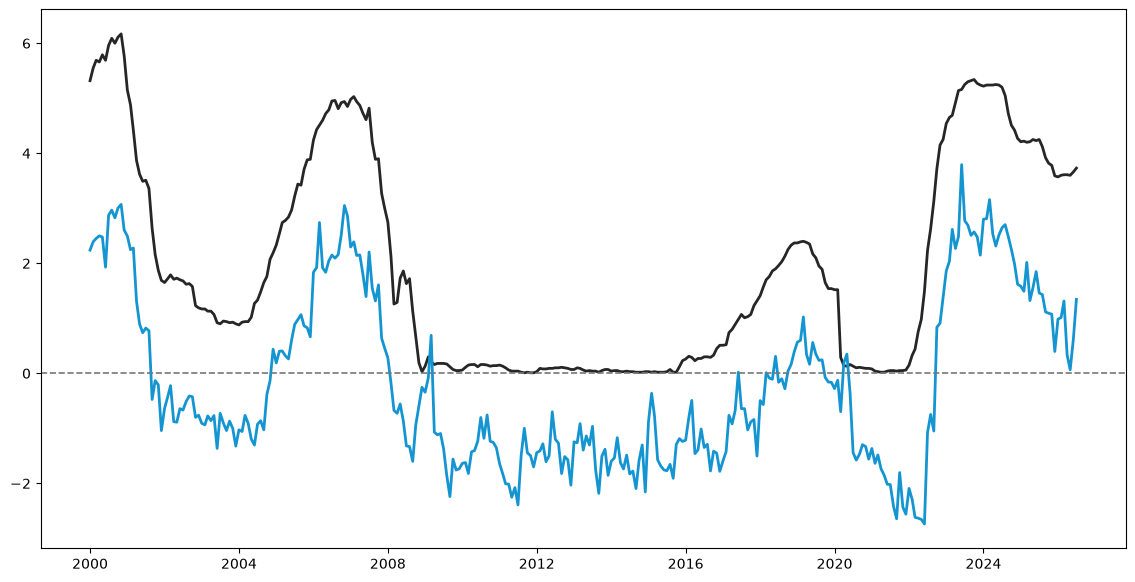

In [74]:
fig, ax = plt.subplots(figsize=(14, 7))

# Nominal interest rate
ax.plot(
    analysis_df.index,
    analysis_df["nominal_rate"],
    color="#262626",
    linewidth=2,
    label="Nominal Rate"
)

# Estimated real interest rate
ax.plot(
    analysis_df.index,
    analysis_df["real_rate_approx"],
    color="#1495D1",
    linewidth=2,
    label="Estimated Real Rate"
)

# Zero-percent reference line
ax.axhline(
    y=0,
    color="#777777",
    linewidth=1.2,
    linestyle="--"
)

In [75]:
ax.set_title(
    "U.S. Nominal and Estimated Real Interest Rates\n"
    f"Three-Month Treasury Bill, "
    f"{chart_start_year}–{chart_end_year}",
    fontsize=16,
    fontweight="bold",
    pad=16
)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Interest Rate (%)", fontsize=11)

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

minimum_rate = min(
    analysis_df["nominal_rate"].min(),
    analysis_df["real_rate_approx"].min()
)

maximum_rate = max(
    analysis_df["nominal_rate"].max(),
    analysis_df["real_rate_approx"].max()
)

ax.set_ylim(minimum_rate - 1, maximum_rate + 1)

(-3.7367133699999995, 7.17)

In [76]:
ax.grid(
    axis="y",
    color="#D9D9D9",
    linestyle="-",
    linewidth=0.7,
    alpha=0.5
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#666666")
ax.spines["bottom"].set_color("#666666")

ax.tick_params(axis="both", colors="#444444")
ax.legend(loc="upper right", frameon=False, fontsize=11)

source_note = (
    "Sources: Federal Reserve Board, H.15 (TB3MS); "
    "Federal Reserve Bank of Cleveland (EXPINF1YR), via FRED.\n"
    "Estimated real rate ≈ 3-month Treasury bill rate "
    "− 1-year expected inflation. Monthly data."
)

fig.text(0.10, 0.02, source_note, ha="left", va="bottom", fontsize=9, color="#555555")

plt.tight_layout(rect=[0, 0.10, 1, 1])

<Figure size 640x480 with 0 Axes>

In [77]:
main_figure_file = (output_directory / "nominal_and_real_interest_rates.png")

fig.savefig(
    main_figure_file,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Figure saved to: {main_figure_file}")

Figure saved to: d:\Project_Intern\us-real-interest-rate-analysis\outputs\nominal_and_real_interest_rates.png


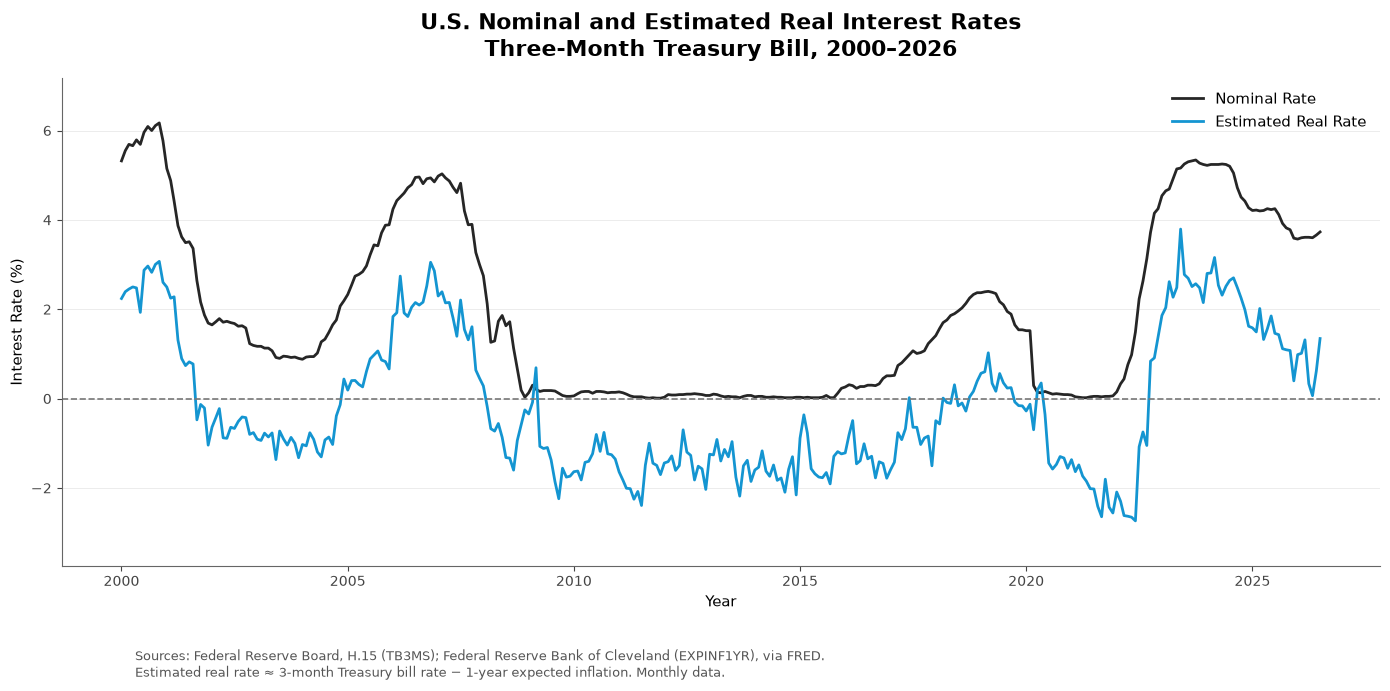

Figure saved to: d:\Project_Intern\us-real-interest-rate-analysis\outputs\nominal_and_real_interest_rates.png


In [79]:
fig, ax = plt.subplots(figsize=(14, 7))

# Nominal interest rate
ax.plot(
    analysis_df.index,
    analysis_df["nominal_rate"],
    color="#262626",
    linewidth=2,
    label="Nominal Rate"
)

# Estimated real interest rate
ax.plot(
    analysis_df.index,
    analysis_df["real_rate_approx"],
    color="#1495D1",
    linewidth=2,
    label="Estimated Real Rate"
)

# Zero-percent reference line
ax.axhline(
    y=0,
    color="#777777",
    linewidth=1.2,
    linestyle="--"
)

ax.set_title(
    "U.S. Nominal and Estimated Real Interest Rates\n"
    f"Three-Month Treasury Bill, "
    f"{chart_start_year}–{chart_end_year}",
    fontsize=16,
    fontweight="bold",
    pad=16
)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Interest Rate (%)", fontsize=11)

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

minimum_rate = min(
    analysis_df["nominal_rate"].min(),
    analysis_df["real_rate_approx"].min()
)

maximum_rate = max(
    analysis_df["nominal_rate"].max(),
    analysis_df["real_rate_approx"].max()
)

ax.set_ylim(minimum_rate - 1, maximum_rate + 1)

ax.grid(
    axis="y",
    color="#D9D9D9",
    linestyle="-",
    linewidth=0.7,
    alpha=0.5
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#666666")
ax.spines["bottom"].set_color("#666666")

ax.tick_params(axis="both", colors="#444444")
ax.legend(loc="upper right", frameon=False, fontsize=11)

source_note = (
    "Sources: Federal Reserve Board, H.15 (TB3MS); "
    "Federal Reserve Bank of Cleveland (EXPINF1YR), via FRED.\n"
    "Estimated real rate ≈ 3-month Treasury bill rate "
    "− 1-year expected inflation. Monthly data."
)

fig.text(0.10, 0.02, source_note, ha="left", va="bottom", fontsize=9, color="#555555")

plt.tight_layout(rect=[0, 0.10, 1, 1])

main_figure_file = (output_directory / "nominal_and_real_interest_rates.png")

fig.savefig(
    main_figure_file,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Figure saved to: {main_figure_file}")

# **Testing the reusable data modules**

The FRED data-retrieval and real-interest-rate calculations have been moved
into reusable Python modules for later use in the Streamlit application.

In [80]:
from src.data_loader import load_interest_rate_data

from src.calculations import (
    build_analysis_dataset,
    get_data_status,
    get_latest_metrics,
)

In [ ]:
# Lấy dữ liệu
raw_data = load_interest_rate_data(
    api_key=fred_api_key,
    start_date="2000-01-01",
)

nominal_df_module = raw_data["nominal_rate"]
expected_df_module = raw_data["expected_inflation"]

In [84]:
display(nominal_df_module.tail())
display(expected_df_module.tail())

,nominal_rate
date,
2026-03-01,3.61
2026-04-01,3.61
2026-05-01,3.60
2026-06-01,3.66
2026-07-01,3.73


,expected_inflation
date,
2026-04-01,3.276398
2026-05-01,3.535256
2026-06-01,3.038866
2026-07-01,2.386001
2026-08-01,2.393703


In [86]:
# Tìm lãi suất thực
analysis_df_module = build_analysis_dataset(
    nominal_df=nominal_df_module,
    expected_df=expected_df_module,
)

analysis_df_module.tail()

,nominal_rate,expected_inflation,real_rate_approx,real_rate_exact,formula_difference,negative_real_rate
date,,,,,,
2026-03-01,3.61,2.295295,1.314705,1.285206,0.029499,False
2026-04-01,3.61,3.276398,0.333602,0.323019,0.010583,False
2026-05-01,3.60,3.535256,0.064744,0.062534,0.002211,False
2026-06-01,3.66,3.038866,0.621134,0.602815,0.018319,False
2026-07-01,3.73,2.386001,1.343999,1.312678,0.031321,False


In [88]:
data_status = get_data_status(
    nominal_df=nominal_df_module,
    expected_df=expected_df_module,
    analysis_df=analysis_df_module,
)

data_status

{'nominal_latest': Timestamp('2026-07-01 00:00:00'),
 'expected_latest': Timestamp('2026-08-01 00:00:00'),
 'analysis_latest': Timestamp('2026-07-01 00:00:00')}

In [89]:
# Chỉ số mới nhất
latest_metrics = get_latest_metrics(
    analysis_df_module
)

latest_metrics

{'date': Timestamp('2026-07-01 00:00:00'),
 'nominal_rate': 3.73,
 'expected_inflation': 2.3860011,
 'real_rate': 1.3439988999999999,
 'is_negative': False}